In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
land = cfeature.NaturalEarthFeature(category='physical', name='land',
                                    scale='50m',
                                    facecolor=cfeature.COLORS['land'])
ocean = cfeature.NaturalEarthFeature(category='physical', name='ocean',
                                     scale='50m',
                                     facecolor=cfeature.COLORS['water'])

In [ ]:
def plot_heatmap_for_basin(
    basin_label, 
    begin_end_types, 
    mslp_rad_types, 
    dfib_all, 
    dfib_track, 
    lanina_years=None, 
    elnino_years=None
):
    # Filter by La Niña/El Niño years if provided
    if lanina_years is not None:
        tids = dfib_all[dfib_all.ISOTIME.dt.year.isin(lanina_years)].TID.unique()
        begin_end_types = [(name, np.intersect1d(ids, tids)) for name, ids in begin_end_types]
        mslp_rad_types = [(name, np.intersect1d(ids, tids)) for name, ids in mslp_rad_types]
        title_suffix = " (La Niña years)"
    elif elnino_years is not None:
        tids = dfib_all[dfib_all.ISOTIME.dt.year.isin(elnino_years)].TID.unique()
        begin_end_types = [(name, np.intersect1d(ids, tids)) for name, ids in begin_end_types]
        mslp_rad_types = [(name, np.intersect1d(ids, tids)) for name, ids in mslp_rad_types]
        title_suffix = " (El Niño years)"
    else:
        title_suffix = ""

    # Prepare a DataFrame to store counts
    heatmap_data = pd.DataFrame(
        0, 
        index=[name for name, _ in begin_end_types], 
        columns=[name for name, _ in mslp_rad_types]
    )
    
    # For each begin/end type
    for begin_end_name, begin_end_ids in begin_end_types:
        # For each mslp/rad type
        for mslp_rad_name, mslp_rad_ids in mslp_rad_types:
            # Find intersection
            intersect_ids = set(begin_end_ids).intersection(set(mslp_rad_ids))
            heatmap_data.loc[begin_end_name, mslp_rad_name] = len(intersect_ids)
    # Plot heatmap
    heatmap_norm = heatmap_data.div(heatmap_data.sum(axis=1), axis=0).fillna(0)

    # Plot normalized heatmap with counts as labels
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    sns.heatmap(
        heatmap_norm,
        annot=heatmap_data,
        fmt="d",
        cmap="YlGnBu",
        ax=ax
    )
    plt.title(f"Normalized Heatmap: {basin_label} - Begin/End Type vs MSLP/Rad Type{title_suffix}")
    plt.ylabel("Begin/End Type")
    plt.yticks(rotation=45)
    plt.xlabel("MSLP/Rad Type")
    plt.show()

In [ ]:
# Load IB data
dfib = pd.read_csv("../IB_track_file/IBTrACS_TC_Size.csv",keep_default_na=False)
dfib['ISOTIME'] = pd.to_datetime(dfib['ISOTIME'])
dfib_all=dfib.copy()
dfib_pre14=dfib[dfib.ISOTIME.dt.year<=2014].copy()
dfib_track=pd.read_csv("../IB_track_file/ibtracs_ERA5_track_pair.csv",keep_default_na=False) # IB track type info
ib_et_id=dfib_track[dfib_track.end_type=='ET'].TID.values
ib_land_id=dfib_track[dfib_track.end_type=='LAND'].TID.values

In [ ]:
# Assign track type for each basin
wp_ms_et_id=dfib_track[(dfib_track.end_type=='ET') & (dfib_track.begin_type=='MS') & (dfib_track.basin_label=='WP')].TID.values
wp_ms_land_id=dfib_track[(dfib_track.end_type=='LAND') & (dfib_track.begin_type=='MS') & (dfib_track.basin_label=='WP')].TID.values
wp_ms_net_id=dfib_track[(dfib_track.end_type=='Non-ET') & (dfib_track.begin_type=='MS') & (dfib_track.basin_label=='WP')].TID.values
wp_nms_et_id=dfib_track[(dfib_track.end_type=='ET') & (dfib_track.begin_type=='Non-MS') & (dfib_track.basin_label=='WP')].TID.values
wp_nms_land_id=dfib_track[(dfib_track.end_type=='LAND') & (dfib_track.begin_type=='Non-MS') & (dfib_track.basin_label=='WP')].TID.values
wp_nms_net_id=dfib_track[(dfib_track.end_type=='Non-ET') & (dfib_track.begin_type=='Non-MS') & (dfib_track.basin_label=='WP')].TID.values
wp_tt_id=dfib_track[(dfib_track.begin_type=='TT') & (dfib_track.basin_label=='WP')].TID.values
wp_id=dfib_track[(dfib_track.basin_label=='WP')].TID.values

na_ms_id=dfib_track[(dfib_track.begin_type=='MS') & (dfib_track.basin_label=='NA')].TID.values
na_nms_et_id=dfib_track[(dfib_track.end_type=='ET') & (dfib_track.begin_type=='Non-MS') & (dfib_track.basin_label=='NA')].TID.values
na_nms_land_id=dfib_track[(dfib_track.end_type=='LAND') & (dfib_track.begin_type=='Non-MS') & (dfib_track.basin_label=='NA')].TID.values
na_nms_net_id=dfib_track[(dfib_track.end_type=='Non-ET') & (dfib_track.begin_type=='Non-MS') & (dfib_track.basin_label=='NA')].TID.values
na_tt_id=dfib_track[(dfib_track.begin_type=='TT') & (dfib_track.basin_label=='NA')].TID.values
na_id=dfib_track[(dfib_track.basin_label=='NA')].TID.values



In [ ]:
# Assign evolution pathways to each track
dfib_all['MSLP']=np.where(dfib_all['MSLP']==0, dfib_all['WMO_PRES'], dfib_all['MSLP'])
dfib_all['index']=np.arange(0,len(dfib_all),1)
dfib_all['lapse']=dfib_all.groupby(['TID'],group_keys=False)['index'].apply(lambda x: x-list(x)[0])
peak_ind=dfib_all.groupby('TID')['MSLP'].idxmin()
dfib_peak=dfib_all.loc[peak_ind].reset_index(drop=True)
end_ind=dfib_all.groupby('TID')['lapse'].idxmax()
dfib_end=dfib_all.loc[end_ind].reset_index(drop=True)
maxisze_ind=dfib_all.groupby('TID')['MeanRad'].idxmax()
dfib_maxsize=dfib_all.loc[maxisze_ind].reset_index(drop=True)


wd_id=dfib_peak[(dfib_peak.MSLP>=970) & (dfib_maxsize.MeanRad<105)].TID.unique() 
wg_id=dfib_peak[(dfib_peak.MSLP>=970) & (dfib_maxsize.MeanRad>=105)].TID.unique()
sd_e_id=dfib_peak[(dfib_peak.MSLP<970) & (dfib_peak.MeanRad<105) & (dfib_end.MeanRad>dfib_peak.MeanRad)].TID.unique()
sd_s_id=dfib_peak[(dfib_peak.MSLP<970) & (dfib_peak.MeanRad<105) & (dfib_end.MeanRad<=dfib_peak.MeanRad)].TID.unique()
sg_e_id=dfib_peak[(dfib_peak.MSLP<970) & (dfib_peak.MeanRad>=105) & (dfib_end.MeanRad>dfib_peak.MeanRad) ].TID.unique()
sg_s_id=dfib_peak[(dfib_peak.MSLP<970) & (dfib_peak.MeanRad>=105) & (dfib_end.MeanRad<=dfib_peak.MeanRad) ].TID.unique()    

wp_begin_end_types = [
    ("MD-ET", wp_ms_et_id),
    ("TD-ET", wp_nms_et_id),
    ("MD-LD", wp_ms_land_id),
    ("TD-LD", wp_nms_land_id),
    ("MD-NT", wp_ms_net_id),
    ("TD-NT", wp_nms_net_id),
    ("TT", wp_tt_id)
]

na_begin_end_types = [
    ("MD", na_ms_id),
    ("TD-ET", na_nms_et_id),
    ("TD-LD", na_nms_land_id),
    ("TD-NT", na_nms_net_id),
    ("TT", na_tt_id)
]

mslp_rad_types = [
    ("WD", wd_id),
    ("WG", wg_id),
    ("SD-E", sd_e_id),
    ("SD-S", sd_s_id),
    ("SG-E", sg_e_id),
    ("SG-S", sg_s_id),
]

wp_begin_end_types2 = [
    ("TD-ET", wp_nms_et_id),
    ("TD-LD", wp_nms_land_id),
    ("TD-NT", wp_nms_net_id),
]

na_begin_end_types2 = [
    ("TD-ET", na_nms_et_id),
    ("TD-LD", na_nms_land_id),
    ("TD-NT", na_nms_net_id),
]

mslp_rad_types2 = [
    ("WD", wd_id),
    ("WG", wg_id),
    ("SD", np.union1d(sd_e_id, sd_s_id)),
    ("SG", np.union1d(sg_e_id, sg_s_id)),
]


In [ ]:
# Helper function to format non-zero percentages
def fmt_nonzero(x):
    return "" if abs(x) < 0.01 else f"{round(x*100)}%"

/global/homes/y/ykh5116/.conda/envs/easy/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/global/homes/y/ykh5116/.conda/envs/easy/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/tmp/ipykernel_1064087/4184893237.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('../figures/size/figure6.jpg',dpi=500,bbox_inches='tight')
/tmp/ipykernel_1064087/4184893237.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('../figures/size/figure6.jpg',dpi=500,bbox_inches='tight')
/global/homes/y/ykh5116/.conda/envs/easy/lib/python3.12/site-packages/IPython/core/pylabtools.py

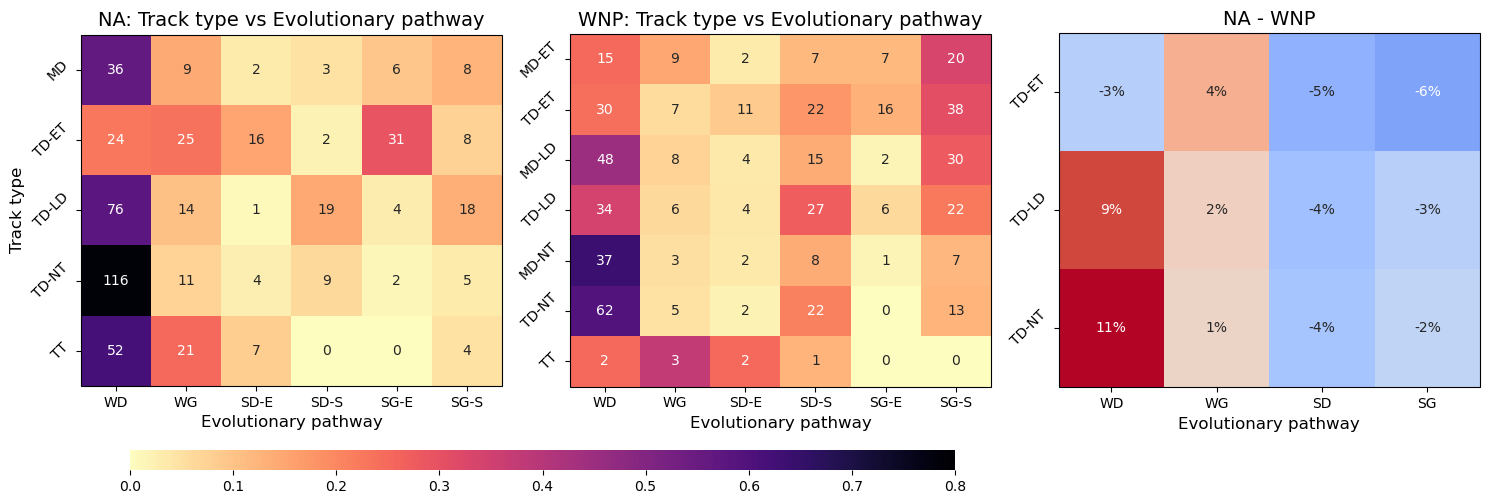

In [ ]:
# Plot Figure 6
fig = plt.figure(figsize=(15,5),layout="tight")
heatmap_data = pd.DataFrame(
    0, 
    index=[name for name, _ in na_begin_end_types], 
    columns=[name for name, _ in mslp_rad_types]
)

for begin_end_name, begin_end_ids in na_begin_end_types:
    # For each mslp/rad type
    for mslp_rad_name, mslp_rad_ids in mslp_rad_types:
        # Find intersection
        intersect_ids = set(begin_end_ids).intersection(set(mslp_rad_ids))
        heatmap_data.loc[begin_end_name, mslp_rad_name] = len(intersect_ids)
# Plot heatmap
heatmap_norm = heatmap_data.div(heatmap_data.sum(axis=1), axis=0).fillna(0)

# Plot normalized heatmap with counts as labels
ax = fig.add_subplot(1,3,1,projection=ccrs.PlateCarree(central_longitude=180))
sns.heatmap(
    heatmap_norm,
    annot=heatmap_data,
    fmt="d",
    cmap="magma_r",
    vmin=0, vmax=0.8,
    ax=ax,
    cbar=False,
)
# pos = ax.get_position()
# ax.set_position([pos.x0, pos.y0, pos.width*1.2, pos.height * 1.2])

ax.set_title("NA: Track type vs Evolutionary pathway", fontsize=14)
ax.set_ylabel("Track type", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=45)
ax.set_xlabel("Evolutionary pathway",fontsize=12)

heatmap_data = pd.DataFrame(
    0, 
    index=[name for name, _ in wp_begin_end_types], 
    columns=[name for name, _ in mslp_rad_types]
)

# For each begin/end type
for begin_end_name, begin_end_ids in wp_begin_end_types:
    # For each mslp/rad type
    for mslp_rad_name, mslp_rad_ids in mslp_rad_types:
        # Find intersection
        intersect_ids = set(begin_end_ids).intersection(set(mslp_rad_ids))
        heatmap_data.loc[begin_end_name, mslp_rad_name] = len(intersect_ids)
# Plot heatmap
heatmap_norm = heatmap_data.div(heatmap_data.sum(axis=1), axis=0).fillna(0)

# Plot normalized heatmap with counts as labels
ax = fig.add_subplot(1,3,2,projection=ccrs.PlateCarree(central_longitude=180))
ax.set_aspect(0.717)
cbar_ax = fig.add_axes([0.09, -0.02, 0.55, 0.04])
sns.heatmap(
    heatmap_norm,
    annot=heatmap_data,
    fmt="d",
    cmap="magma_r",
    ax=ax,
    vmin=0, vmax=0.8,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={"orientation":"horizontal"}
)
# get the position of the heatmap to stretch it to fit better
ax.set_title("WNP: Track type vs Evolutionary pathway", fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=45)
ax.set_xlabel("Evolutionary pathway",fontsize=12)

heatmap_data_basin1 = pd.DataFrame(
    0, 
    index=[name for name, _ in na_begin_end_types2], 
    columns=[name for name, _ in mslp_rad_types2]
)
heatmap_data_basin2 = pd.DataFrame(
    0, 
    index=[name for name, _ in wp_begin_end_types2], 
    columns=[name for name, _ in mslp_rad_types2]
)

# Fill counts for basin 1
for begin_end_name, begin_end_ids in na_begin_end_types2:
    for mslp_rad_name, mslp_rad_ids in mslp_rad_types2:
        intersect_ids = set(begin_end_ids).intersection(set(mslp_rad_ids))
        heatmap_data_basin1.loc[begin_end_name, mslp_rad_name] = len(intersect_ids)

# Fill counts for basin 2
for begin_end_name, begin_end_ids in wp_begin_end_types2:
    for mslp_rad_name, mslp_rad_ids in mslp_rad_types2:
        intersect_ids = set(begin_end_ids).intersection(set(mslp_rad_ids))
        heatmap_data_basin2.loc[begin_end_name, mslp_rad_name] = len(intersect_ids)

# Normalize by total counts in each basin
heatmap_norm_basin1 = heatmap_data_basin1.div(heatmap_data_basin1.values.sum()).fillna(0)
heatmap_norm_basin2 = heatmap_data_basin2.div(heatmap_data_basin2.values.sum()).fillna(0)

# Calculate difference
heatmap_diff = heatmap_norm_basin1.reindex(index=heatmap_norm_basin2.index, columns=heatmap_norm_basin2.columns, fill_value=0) - heatmap_norm_basin2
annot_data_na = heatmap_diff.map(fmt_nonzero)
# Plot difference heatmap
ax = fig.add_subplot(1,3,3,projection=ccrs.PlateCarree(central_longitude=180))
ax.set_aspect(1.12)
sns.heatmap(
    heatmap_diff,
    annot=annot_data_na,
    fmt="s",
    cmap="coolwarm",
    center=0,
    cbar=False
)
ax.set_title("NA - WNP",fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=45)
ax.set_xlabel("Evolutionary pathway",fontsize=12)

# save heatmap data
plt.savefig('../figures/figure6.jpg',dpi=500,bbox_inches='tight')

In [ ]:
heatmap_data = pd.DataFrame(
    0, 
    index=[name for name, _ in na_begin_end_types], 
    columns=[name for name, _ in mslp_rad_types]
)

for begin_end_name, begin_end_ids in na_begin_end_types:
    # For each mslp/rad type
    for mslp_rad_name, mslp_rad_ids in mslp_rad_types:
        # Find intersection
        intersect_ids = set(begin_end_ids).intersection(set(mslp_rad_ids))
        heatmap_data.loc[begin_end_name, mslp_rad_name] = len(intersect_ids)
# Save heatmap data for later use
heatmap_data.to_csv('../figures/size/heatmap_data_na.csv')

heatmap_data = pd.DataFrame(
    0, 
    index=[name for name, _ in wp_begin_end_types], 
    columns=[name for name, _ in mslp_rad_types]
)

# For each begin/end type
for begin_end_name, begin_end_ids in wp_begin_end_types:
    # For each mslp/rad type
    for mslp_rad_name, mslp_rad_ids in mslp_rad_types:
        # Find intersection
        intersect_ids = set(begin_end_ids).intersection(set(mslp_rad_ids))
        heatmap_data.loc[begin_end_name, mslp_rad_name] = len(intersect_ids)
# Save heatmap data for later use
heatmap_data.to_csv('../figures/size/heatmap_data_wp.csv')